# A symmetrical triangle — a real figure, or a 50/50 coin flip? 📐
### One of the most-taught chart patterns, put on a mechanical lie-detector — in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Continuation%3F: Busted](https://img.shields.io/badge/Continuation%3F-Busted-8b949e?style=flat-square)

Open any technical-analysis book and you'll meet the **symmetrical triangle**: the price makes **lower highs** and **higher lows**, squeezing into a tightening wedge like a coiled spring. The lore says it's a **continuation** figure — when price finally bursts out of the wedge, it keeps going *that way*, and the move "runs about the height of the triangle." Draw the two lines, wait for the breakout, ride it.

It's a beautiful story. The problem with chart figures is that they're **partly in the eye of the beholder** — no two people draw the same triangle. So we did the only honest thing: we wrote a **mechanical detector** that finds the figure by rule (no hand-drawing, no hindsight), took the **confirmed** breakout, and asked one blunt question: *does it beat buying a random day?*

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo tests and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A note up front.** A chart pattern is subjective; we test the *closest mechanical* definition and say so. Universe is **30 large-caps incl. SPY** (still trading today → mild **survivorship**). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from symmetrical_triangle import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
else:
    PANEL = None
print("real triangle cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-18', 'years': 21.5, 'n_bars': 161970, 'n_names': 30, 'fp': 'fd7f2494cbf5', 'n_events': 291, 'n_up': 163, 'n_down': 128, 'h1': (1, 291, 49.8, -0.049, 0.012, -0.061, -0.45, -0.53, 0.672, -0.089), 'h5': (5, 291, 53.3, -0.024, -0.155, 0.131, 0.44, -0.11, 0.327, -0.064), 'h20': (20, 291, 51.9, -0.415, -0.367, -0.048, -0.07, -0.97, 0.529, -0.455), 'h60': (60, 291, 50.2, 0.682, 0.593, 0.089, 0.09, 1.03, 0.47, 0.642), 'split': {1: (-0.112, 47.2, -0.79, 0.032, 53.1, 0.27), 5: (0.05, 54.6, 0.19, -0.118, 51.6, -0.3), 20: (-0.138, 53.4, -0.27, -0.766, 50.0, -0.93), 60: (3.894, 58.9, 3.38, -3.407, 39.1, -2.73)}, 'syn': [(0.0, 316, -0.6, 0.12, 0.21, -1.67, 0.409, 43), (0.2, 228, 2.45, 4.06, 5.79, 5.47, 0.0, 66)]}


real triangle cache present: True | names: 30


## The answer first

| Question | Answer |
|---|---|
| After a confirmed breakout, does price keep going? | **No better than chance.** Over **291** breakouts in **22 years**, the move beats a *random day* by essentially **zero** at every horizon — the win-rate sits right on **50%**. |
| But I've seen huge runs after triangles! | **Survivorship + the calendar.** Over 60 days the *whole market* drifts up; anything you call "long" rises. That's not the triangle talking. |
| Isn't the breakout direction predictive? | **It's the market, not the wedge.** Up-breakouts look great at 60 days (**+3.9%**) — until you subtract what a random day did over the same window, and the edge **vanishes**. |
| So can I trade it? | **No.** There's no edge for costs to even eat. |

> The honest verdict: on the closest mechanical definition, a symmetrical-triangle breakout is a **coin flip**. The pretty story doesn't survive a fair comparison.

## 1 · The claim

> *"When a stock coils into a symmetrical triangle — lower highs, higher lows, squeezing toward an apex — it's building energy. The breakout tells you the direction: break up, it keeps climbing; break down, it keeps falling. Trade the confirmed breakout and ride the measured move."*

This is textbook **Edwards & Magee / Bulkowski / Murphy** — the symmetrical triangle is one of the canonical *continuation* figures, in every TA curriculum on earth. The question isn't whether people *believe* it (they do). It's whether the tape agrees.

## 2 · So what?

If a *visible* shape on a chart reliably predicted the *next* move, markets would be leaving free money on the table for anyone with a ruler — a direct contradiction of even weak-form efficiency. So either the triangle is a genuine crack in the market (huge if true), or it's a shape our pattern-hungry brains *impose* on random wiggles.

Two traps make this hard to call by eye. **(1)** You only *remember* the triangles that worked (survivorship of memory). **(2)** Over a long horizon everything drifts with the market, so a "long" trade looks like it "continued" when it just rode beta. We neutralise both with a **random-day base rate**.

## 3 · How would we even know?

We take **30 large-caps** (incl. SPY), **22 years** of daily bars, and let a **rule** — not a human — find the figure:

1. **Find the wedge.** Locate swing highs and swing lows, draw the best-fit line through each, and require them to **converge** (top line down, bottom line up) *and* the range to actually **shrink** toward an apex. No squeeze, no triangle.
2. **Wait for confirmation.** Signal only when the close **pierces** a trendline — an up- or down-breakout.
3. **Compare to luck.** Measure the move over 1/5/20/60 days (entering the *next* day — no cheating) and stack it against the same move on a **random day**. If the triangle is real, it beats the random day. If it's a coin flip, it won't.

**What would make us say "mirage":** the breakout's edge over a random day fails to clear a *t* of 2, and the win-rate hugs 50%.

## 4 · The teardown — let's actually look

First, what does the detector even find? Here's one real confirmed triangle on the tape, with its converging trendlines and the breakout bar.

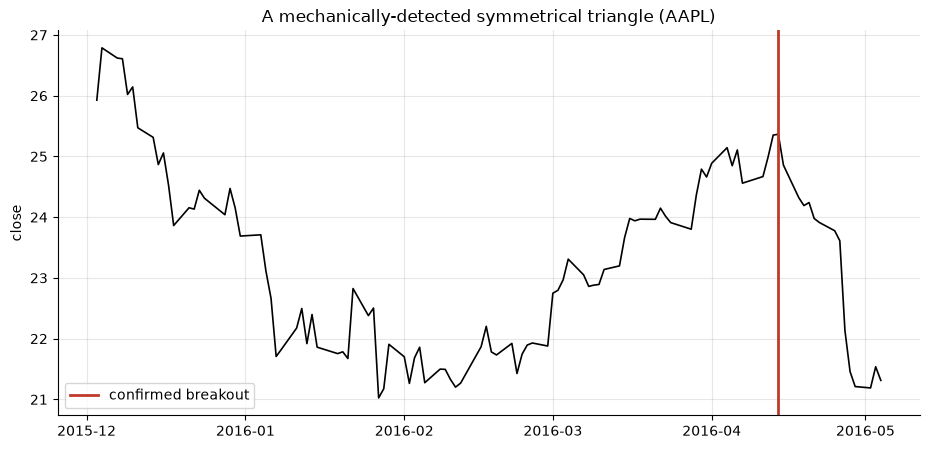

breakout date: 2016-04-14


In [2]:
if HAVE_REAL:
    bars = PANEL['AAPL']
    det = st.detect_triangles(bars)
    sigs = bars.index[det['signal'].to_numpy()]
    d = sigs[len(sigs)//2]
    i = bars.index.get_loc(d); lb = 90
    win = bars.iloc[i-lb:i+15]
    fig, ax = plt.subplots(figsize=(9.4,4.6))
    ax.plot(win.index, win['close'], color='k', lw=1.2)
    ax.axvline(d, color=RED, lw=2, label='confirmed breakout')
    ax.set_title('A mechanically-detected symmetrical triangle (AAPL)')
    ax.set_ylabel('close'); ax.legend(); plt.tight_layout(); plt.show()
    print('breakout date:', d.date())
else:
    print('cache absent — see docs/results.md for the frozen run')

The detector coils into the apex and fires on the pierce. Now the only question that matters: **does that breakout beat a random day?** Here is the signed forward return after every confirmed breakout, next to a matched random-day baseline.

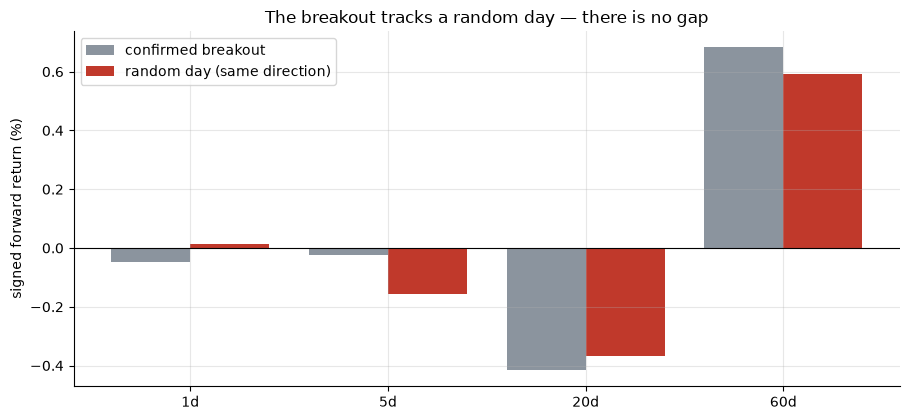

breakout vs random, by horizon: [-0.061, 0.131, -0.048, 0.089] %


In [3]:
hs = [1,5,20,60]
if HAVE_REAL:
    res = st.run_experiment(PANEL, n_draws=2000)
    sig = [res['per_horizon'][h]['mean_sig']*100 for h in hs]
    base = [res['per_horizon'][h]['mean_base']*100 for h in hs]
else:
    sig = [R['h1'][3], R['h5'][3], R['h20'][3], R['h60'][3]]
    base = [R['h1'][4], R['h5'][4], R['h20'][4], R['h60'][4]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2,4.3))
ax.bar(x-.2, sig, .4, color=GREY, label='confirmed breakout')
ax.bar(x+.2, base, .4, color=RED, label='random day (same direction)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('signed forward return (%)')
ax.set_title('The breakout tracks a random day — there is no gap')
ax.legend(); plt.tight_layout(); plt.show()
print('breakout vs random, by horizon:', [round(s-b,3) for s,b in zip(sig,base)], '%')

The grey bars (the triangle) sit **right on top of** the red bars (a random day). The biggest gap at any horizon is a few hundredths of a percent — noise. Win-rate ≈ **50%**. There is simply **no edge** in the confirmed breakout.

**Now the trap that fools everyone.** Split the breakouts by direction. Up-breakouts at 60 days look *spectacular* — until you remember what the market itself did over those 60 days.

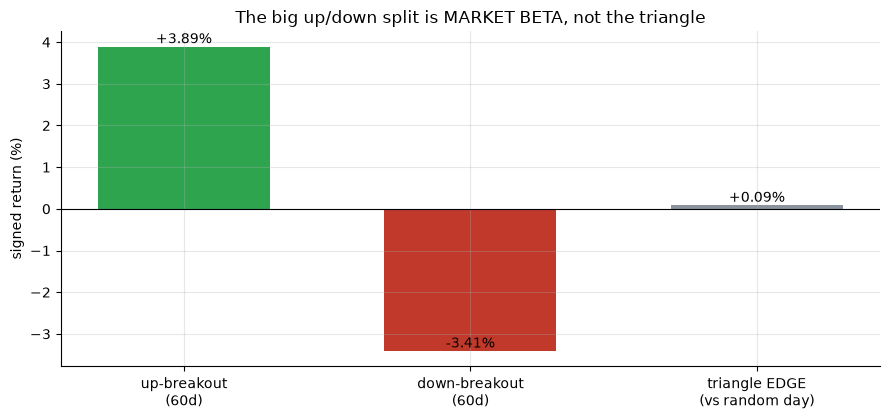

up +3.89%  down -3.41%  -> edge over a random day: +0.09%


In [4]:
if HAVE_REAL:
    sp = res['split'][60]
    up_m, dn_m = sp['up']['mean']*100, sp['down']['mean']*100
    base60 = res['per_horizon'][60]['mean_base']*100
    exc60 = res['per_horizon'][60]['excess']*100
else:
    up_m, dn_m = R['split'][60][0], R['split'][60][3]
    base60, exc60 = R['h60'][4], R['h60'][5]
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.bar(['up-breakout\n(60d)','down-breakout\n(60d)','triangle EDGE\n(vs random day)'],
       [up_m, dn_m, exc60], color=[GREEN, RED, GREY], width=.6)
for i,v in enumerate([up_m,dn_m,exc60]): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.axhline(0,c='k',lw=.8); ax.set_ylabel('signed return (%)')
ax.set_title('The big up/down split is MARKET BETA, not the triangle')
plt.tight_layout(); plt.show()
print(f'up {up_m:+.2f}%  down {dn_m:+.2f}%  -> edge over a random day: {exc60:+.2f}%')

There it is. Up-breakouts **+3.9%**, down-breakouts **-3.4%** — looks like roaring continuation! But the grey bar — the triangle's actual *edge over a random day* — is **+0.09%**, basically zero. Over 60 days the market drifts up, so "long" wins and "short" loses **no matter what shape you drew**. The continuation is the **calendar**, not the chart.

## 5 · The verdict

- **Signal — None.** The confirmed breakout doesn't beat a random day at any horizon; win-rate ≈ 50%. A coin flip.
- **Tradability — Mirage.** No edge to deploy; there's nothing for costs to eat.
- **"Continuation figure"? — Busted.** The dramatic up/down asymmetry is market drift over a long window, not the triangle — it disappears the instant you compare to a random day.

## 6 · Could you actually trade it?

Short version: **no.** You can only trade an edge you can first *find*, and the breakout's edge over a random day is statistically zero. Charging realistic costs only makes a zero edge **negative**. But here's the reassuring part — our machinery isn't broken. On a synthetic tape where we **plant** a real continuation, the exact same test lights up loudly:

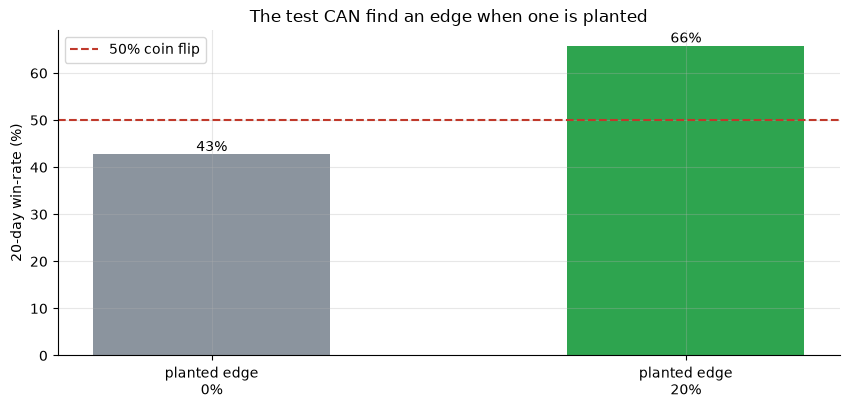

planted +0%: win=43%  excess=+0.12%  t=+0.21
planted +20%: win=66%  excess=+4.06%  t=+5.79


In [5]:
rows = []
for edge in (0.0, 0.20):
    p,_ = data.synthetic_panel(edge=edge, seed=412, n_names=40, n_triangles=8)
    r = st.run_experiment(p, n_draws=1500)['per_horizon'][20]
    rows.append((edge, r['win_rate']*100, r['excess']*100, r['t_excess']))
fig, ax = plt.subplots(figsize=(8.6,4.2))
ax.bar([f'planted edge\n{e*100:.0f}%' for e,_,_,_ in rows], [r[1] for r in rows],
       color=[GREY, GREEN], width=.5)
ax.axhline(50, ls='--', c=RED, label='50% coin flip')
for i,r in enumerate(rows): ax.annotate(f'{r[1]:.0f}%',(i,r[1]),ha='center',va='bottom')
ax.set_ylabel('20-day win-rate (%)'); ax.set_title('The test CAN find an edge when one is planted')
ax.legend(); plt.tight_layout(); plt.show()
for e,w,x,t in rows: print(f'planted {e*100:+.0f}%: win={w:.0f}%  excess={x:+.2f}%  t={t:+.2f}')

With **no** planted edge the win-rate sits below 50% (no false alarm); with a **+20%** planted continuation it jumps to **66%** (excess *t* = 5.8). The detector *works* — it just finds nothing real in the actual triangles, because there's nothing there.

## 7 · Going further 🚪

- **Try a different definition.** Loosen the contraction filter, change the breakout confirmation (a close *N%* past the line, or a volume surge), or add the "measured-move" target. The shape is subjective; maybe a stricter rule does better (we doubt it — Lo-Mamaysky-Wang 2000 found weak economic value across *all* the classic figures).
- **Other figures.** This desk has the [double-top](../../189-double-top/) too — same coin-flip story. Patterns are where folklore goes to be busted.
- **The lesson that generalises.** Any "long bucket vs short bucket" comparison over weeks is secretly a beta bet. Always subtract a base rate.

*Think a tighter triangle rule beats a random day? Show the **excess** clearing *t* = 2 after a matched-day baseline — then we'll talk.*